In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
sys.path.append('../src')

from core import InteractionCore_CRPropA_pdis

In [2]:
data_files = {
    'path' : os.path.abspath('/home/leonel/GitProjects/CRPropa3/data-2021-07-30/data/'),
    
    'photodisintegration': {
        'rates_cmb' : 'Photodisintegration/rate_CMB.txt',
        'branchings_cmb' : 'Photodisintegration/branching_CMB.txt',
        'rates_ebl' : 'Photodisintegration/rate_EBL_LopezSaldana21.txt',
        'branchings_ebl' : 'Photodisintegration/branching_EBL_LopezSaldana21.txt',
    },

    'photopionproduction': {
        'rates_cmb' : 'PhotoPionProduction/rate_CMB.txt',
    } 
}

data_files['photodisintegration']['rates_ebl'] = 'Photodisintegration/rate_IRB_Gilmore12.txt'
data_files['photodisintegration']['branchings_ebl'] = 'Photodisintegration/branching_IRB_Gilmore12.txt'

data_files['photodisintegration']['rates_ebl'] = 'Photodisintegration/rate_IRB_Stecker16_upper.txt'
data_files['photodisintegration']['branchings_ebl'] = 'Photodisintegration/branching_IRB_Stecker16_upper.txt'

ic1 = InteractionCore_CRPropA_pdis(data_files)

For nucleus (8, 14) some products were not found when creating light yields tensor.
For nucleus (7, 14) some products were not found when creating light yields tensor.
For nucleus (7, 13) some products were not found when creating light yields tensor.
For nucleus (6, 12) some products were not found when creating light yields tensor.
For nucleus (6, 10) some products were not found when creating light yields tensor.
For nucleus (5, 10) some products were not found when creating light yields tensor.
For nucleus (3, 6) some products were not found when creating light yields tensor.
problem with product [5. 9.] of nucleus (8, 14)
problem with product [5. 9.] of nucleus (7, 14)
problem with product [5. 9.] of nucleus (7, 13)
problem with product [5. 9.] of nucleus (6, 12)
problem with product [5. 9.] of nucleus (6, 10)
problem with product [5. 9.] of nucleus (5, 10)
problem with product [2. 5.] of nucleus (3, 6)
problem with product [3. 5.] of nucleus (3, 6)
problem with product [5. 9.] of

# Illustrating how the injection composition changes the distribution

Text(0, 0.5, 'Relative abundance [arb. units]')

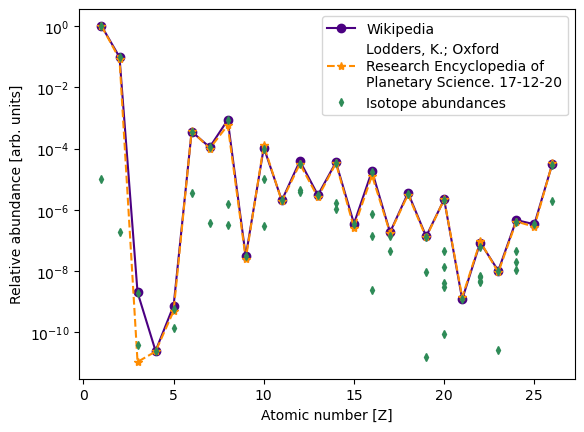

In [3]:
from pandas import read_csv
chem_abund_1 = read_csv('Chemical_abundances.csv', header=1, names=['Z', 'dens']) # relative to silicon
chem_abund_2 = read_csv('Atomic_abundances.csv', header=3, names=['Z', 'val', 'err'])
elem_abund = read_csv('isotope_relative_abundances.csv', header=1, names=['Z', 'A', 'min', 'max'])

chem_abund_1['dens'] /= chem_abund_1['dens'].sum()

abund = lambda val: 10**(val - 12)
chem_abund_2['val'] = chem_abund_2['val'].apply(abund)


plt.plot(chem_abund_1['Z'], chem_abund_1['dens'] / chem_abund_1['dens'][0], '-o', c='indigo', label='Wikipedia')
plt.plot(chem_abund_2['Z'], chem_abund_2['val'], '--*', c='darkorange', label='Lodders, K.; Oxford\nResearch Encyclopedia of\nPlanetary Science. 17-12-20')

eabund = np.hstack([chem_abund_1.loc[chem_abund_1['Z'] == Zval]['dens'].values for Zval in elem_abund['Z']])
plt.plot(elem_abund['Z'], elem_abund['min'] * eabund / chem_abund_1['dens'][0], '-d', c='seagreen', ms=4, lw=0, label='Isotope abundances')

plt.semilogy()
plt.legend()
plt.xlabel('Atomic number [Z]')
plt.ylabel('Relative abundance [arb. units]')

In [4]:
br = np.logspace(9, 10, 10)
distances = np.logspace(-1.5, 2.1, 100)
boostidx = 8

# injecting only surrogates
alpha, mr, tr, _ = ic1.get_distribution_parameters(mass_lims=(56, 0), injection_type=('only species', (26, 56)), absorption_type=('only mass', [1]))
alpha1 = np.zeros_like(alpha)
# injection based on PAO best fit 2017
alpha1[ic1.species.index((14, 28))] = .046
alpha1[ic1.species.index((7, 14))] = .281
alpha1[ic1.species.index((2, 4))] = .673
boosts, total1 = ic1.pdf_boost_range(distances, alpha1, mass_range=mr, boost_range=br, true_range=tr)

# injecting all species in mass groups equally
alpha2 = np.zeros_like(alpha)
alpha2[ic1.species.index((26, 56)):ic1.species.index((2, 4))] = 1 / (ic1.species.index((2, 4)) - ic1.species.index((26, 56)))
boosts, total2 = ic1.pdf_boost_range(distances, alpha2, mass_range=mr, boost_range=br, true_range=tr)

# injecting according to solar system abundances
alpha3 = np.zeros_like(alpha)

for idx, (Z, A) in enumerate(ic1.species):
    if Z <= 1:
        continue
    
    chem_ab = chem_abund_1[chem_abund_1['Z'] == Z]['dens']
    elem_ab = elem_abund.loc[np.logical_and(elem_abund['Z'] == Z, elem_abund['A'] == A)][['min', 'max']]
    elem_ab = elem_ab.values[np.logical_not(np.isnan(elem_ab.values))]

    if elem_ab.size == 0:
        elem_ab = [0]

    alpha3[idx] = chem_ab * min(elem_ab)

alpha3 /= sum(alpha3)

boosts, total3 = ic1.pdf_boost_range(distances, alpha3, mass_range=mr, boost_range=br, true_range=tr)

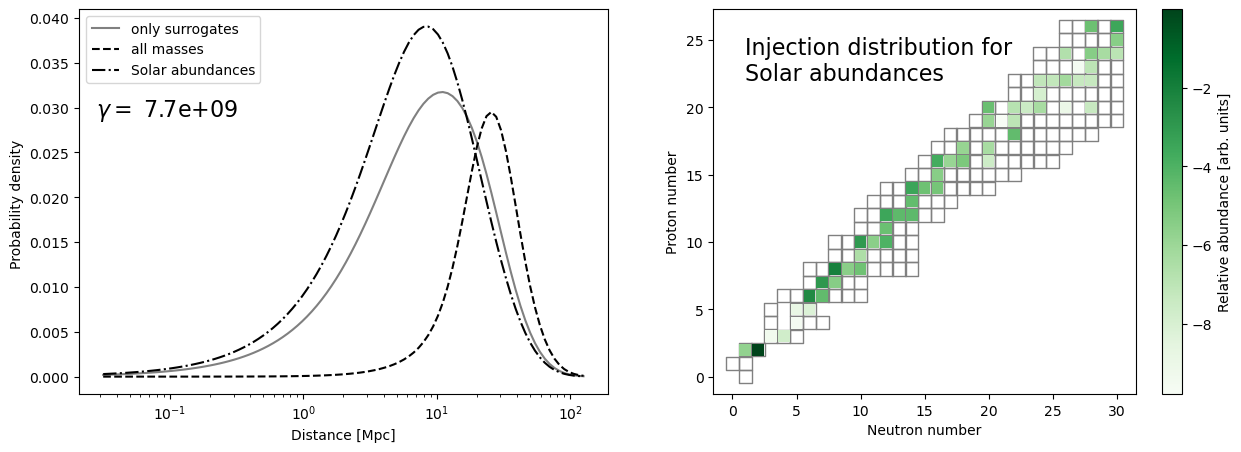

In [5]:
f, axes = plt.subplots(1, 2, figsize=(15, 5))

plt.sca(axes[0])
plt.semilogx(distances, total1[boostidx, :], label='only surrogates', c='grey')
plt.semilogx(distances, total2[boostidx, :], label='all masses', ls='--', c='k')
plt.semilogx(distances, total3[boostidx, :], label='Solar abundances', ls='-.', c='k')

plt.legend()


plt.text(.028, .029, f'$\gamma =$ {br[boostidx]:2.1e}', fontsize=16)
plt.xlabel('Distance [Mpc]')
plt.ylabel('Probability density ')

plt.sca(axes[1])

z = np.array([ic1.species[k][0] for k in mr])
a = np.array([ic1.species[k][1] for k in mr])

varalpha = alpha3.copy()
varalpha[varalpha == 0] = None
varalpha = np.log10(varalpha)

plt.scatter(a-z, z, s=90, marker='s', ec='grey', fc='none')

cmap = plt.get_cmap('Greens')
plt.scatter(a-z, z, s=70, marker='s', c=varalpha, ec='none', cmap=cmap)
plt.colorbar(label='Relative abundance [arb. units]')
plt.text(1, 22, 'Injection distribution for\nSolar abundances', fontsize=16)

plt.xlabel('Neutron number');
plt.ylabel('Proton number');

Adding all possibilities of injection as a band

Text(0, 0.5, 'Probability Distribution')

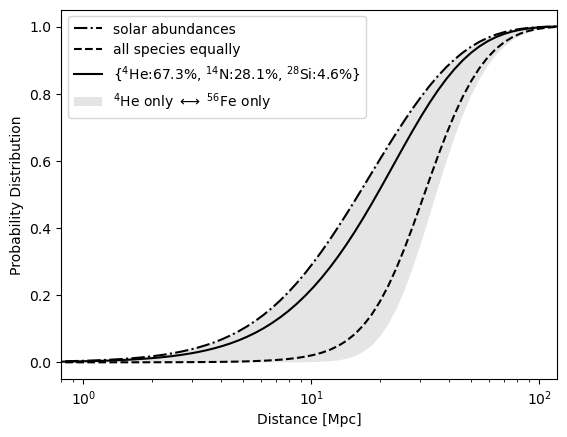

In [6]:
from scipy.integrate import cumtrapz

# Computing base distributions
alpha, mr, tr, _ = ic1.get_distribution_parameters(mass_lims=(56, 0), injection_type=('only species', (26, 56)), absorption_type=('only mass', [1]))
_, total_56 = ic1.cdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

alpha, mr, tr, _ = ic1.get_distribution_parameters(mass_lims=(4, 0), injection_type=('only species', (2, 4)), absorption_type=('only mass', [1]))
_, total_4 = ic1.cdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)


plt.semilogx(distances, cumtrapz(total3[boostidx, :], distances, initial=0), label='solar abundances', ls='-.', c='k')
plt.semilogx(distances, cumtrapz(total2[boostidx, :], distances, initial=0), label='all species equally', ls='--', c='k')
plt.semilogx(distances, cumtrapz(total1[boostidx, :], distances, initial=0), label='{$^4 \mathrm{He}$:67.3%, $^{14} \mathrm{N}$:28.1%, $^{28}\mathrm{Si}$:4.6%}', c='k')
plt.fill_between(distances, total_4[boostidx, :], total_56[boostidx, :], alpha=.2, fc='grey', label='$^4\mathrm{He}$ only $\longleftrightarrow$ $^{56}\mathrm{Fe}$ only')

plt.legend()

plt.xlim(.8, 120)
plt.xlabel('Distance [Mpc]')
plt.ylabel('Probability Distribution')

### Studying mass dependence of moments

In [9]:
boostidx = 9
br = np.logspace(8.5, 10.5, 10)
br = np.array([2, 5, 10, 20, 50, 80, 100, 120, 150, 200]) * 1e8
distances = np.logspace(0, 1.7, 100)

species = []
allmoms = []
for spec in ic1.species[::1]:
    alpha, mr, tr, minitensor = ic1.get_distribution_parameters(mass_lims=(spec[1], 0), injection_type=('only species', spec), absorption_type=('only mass', [1]))
    moms = ic1.pdf_moments_boost_range(alpha, mr, br, tr)

    species.append(spec)
    allmoms.append(moms)

In [10]:
rates_per_nucleon = []
for bidx in range(10):
    rates = np.diag(-ic1.interpolator(br[bidx]))
    rate_per_nucleon = np.mean([rate / A for rate, (_, A) in zip(rates, ic1.species)])

    rates_per_nucleon.append(rate_per_nucleon)

Text(0, 0.5, 'Mean in units of $\\lambda_1^{-1}$')

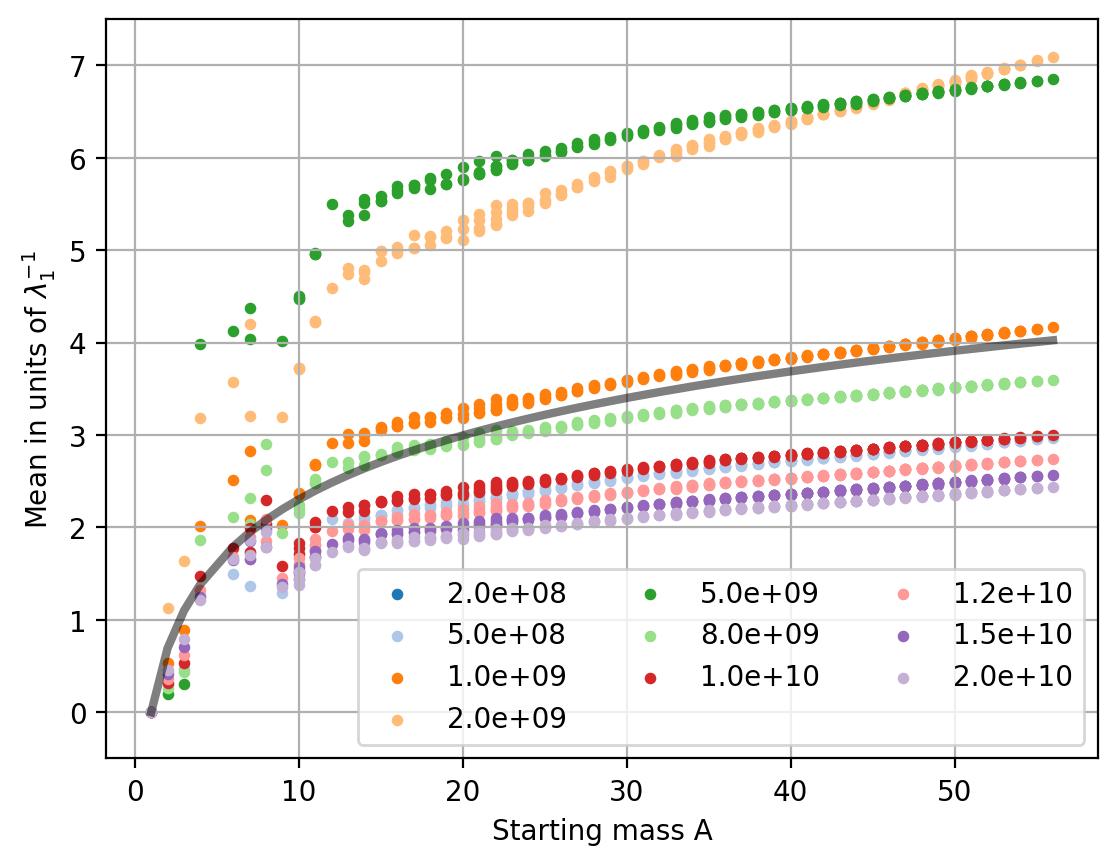

In [11]:
plt.subplots(dpi=200)
cmap = plt.get_cmap('tab20')

for bidx in range(10):
    plt.scatter([s[1] for s in species], [allms[bidx] * rates_per_nucleon[bidx] for allms in allmoms], s=10, label=f'{br[bidx]:2.1e}', color=cmap(bidx))

plt.plot([s[1] for s in species], [np.log(s[1]) for s in species], lw=3, c='k', alpha=.5)

# plt.semilogy()
plt.legend(ncol=3)
# plt.axvline(8)

plt.ylim(-.5, 7.5)
plt.grid(which='both')
plt.xlabel('Starting mass A')
plt.ylabel('Mean in units of $\lambda_1^{-1}$')

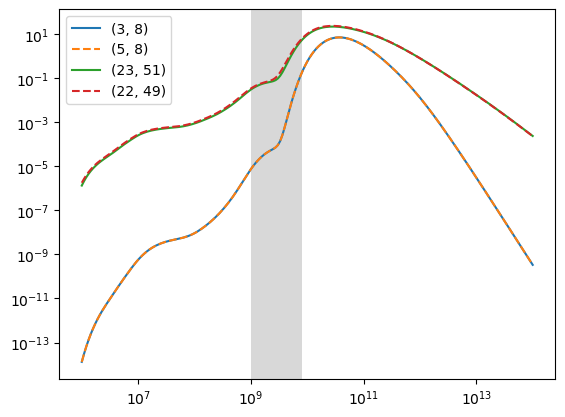

In [12]:
ic1.species[176:]

plt.loglog(ic1.boosts, -ic1.tensor[177, 177, :], label=ic1.species[177])
plt.loglog(ic1.boosts, -ic1.tensor[176, 176, :], ls='--', label=ic1.species[176])


plt.loglog(ic1.boosts, -ic1.tensor[17, 17, :], label=ic1.species[17])
plt.loglog(ic1.boosts, -ic1.tensor[27, 27, :], ls='--', label=ic1.species[27])


plt.legend()

plt.axvspan(1e9, 8e9, fc='grey', alpha=.3) # range where the means deviate the most from the 

## Injection differences among members of mass group

Text(0, 0.5, 'Probability Distribution')

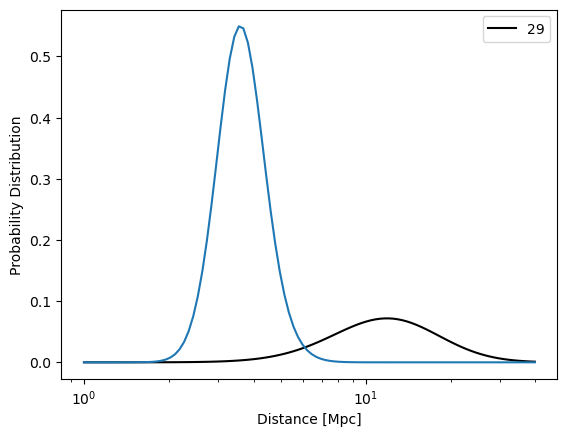

In [13]:
boostidx = 9
br = np.logspace(9, 10, 10)
distances = np.logspace(0, 1.6, 100)

alpha, mr, tr, minitensor = ic1.get_distribution_parameters(mass_lims=(29, 0), injection_type=('only species', (14, 29)), absorption_type=('only mass', [1]))
_, total_29 = ic1.pdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)
plt.semilogx(distances, total_29[boostidx, :], label='29', ls='-', c='k')

from scipy.interpolate import interp1d
redmat = interp1d(ic1.boosts, minitensor)(br[boostidx])

def hypoexp_equivalent(L, T, alpha=None):
    from UHECR_statistics import pdf

    complete_row = np.isclose(redmat.dot(np.ones(len(T))), 0)

    last_rate = np.mean(T.dot(np.ones(len(T)))[np.logical_not(complete_row)])

    hypoexp_T = np.diag(np.append(np.diag(T)[complete_row], last_rate)) - np.diag(np.diag(T)[complete_row], 1)
    hypoexp_alpha = alpha[:len(hypoexp_T)]

    return pdf(L, hypoexp_T, hypoexp_alpha)

plt.semilogx(distances, hypoexp_equivalent(distances, redmat, alpha))

plt.legend()
plt.xlabel('Distance [Mpc]')
plt.ylabel('Probability Distribution')

Text(0, 0.5, 'Probability Distribution')

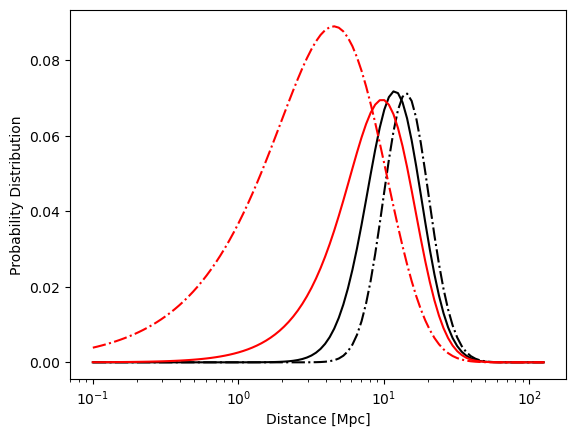

In [6]:
boostidx = 9
br = np.logspace(9, 10, 10)
distances = np.logspace(-1, 2.1, 100)

# Computing base distributions
alpha, mr, tr, minitensor = ic1.get_distribution_parameters(mass_lims=(56, 0), injection_type=('only species', (26, 56)), absorption_type=('only mass', [1]))
_, total_56 = ic1.pdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

alpha, mr, tr, minitensor = ic1.get_distribution_parameters(mass_lims=(29, 0), injection_type=('only species', (14, 29)), absorption_type=('only mass', [1]))
_, total_29 = ic1.pdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

plt.semilogx(distances, total_56[boostidx, :], label='56', ls='-.', c='k')
plt.semilogx(distances, total_29[boostidx, :], label='29', ls='-', c='k')

# Computing base distributions
alpha, mr, tr, minitensor = ic1.get_distribution_parameters(mass_lims=(4, 0), injection_type=('only species', (2, 4)), absorption_type=('only mass', [1]))
_, total_4 = ic1.pdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

alpha, mr, tr, minitensor = ic1.get_distribution_parameters(mass_lims=(13, 0), injection_type=('only species', (7, 13)), absorption_type=('only mass', [1]))
_, total_14 = ic1.pdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

plt.semilogx(distances, total_4[boostidx, :], label='4', ls='-.', c='r')
plt.semilogx(distances, total_14[boostidx, :], label='14', ls='-', c='r')


plt.semilogx()
plt.xlabel('Distance [Mpc]')
plt.ylabel('Probability Distribution')

## Computing production of light secondaries

In [13]:
light_prods = ic1.light_secondaries_production(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

Text(0.5, 1.0, 'Yields of light secondaries vs distance')

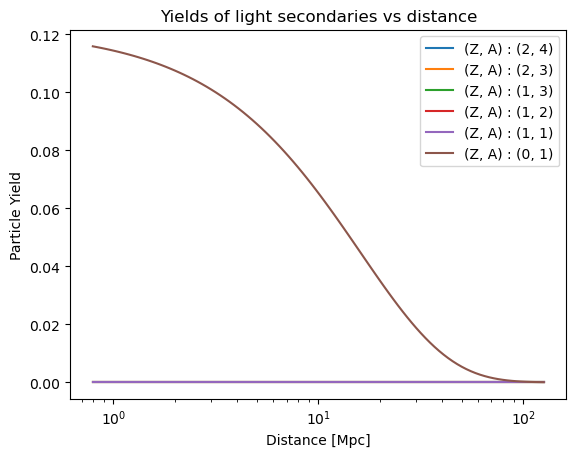

In [14]:
daughters = [(2, 4), (2, 3), (1, 3), (1, 2), (1, 1), (0, 1)]

for nuc, particle_yield in zip(daughters, light_prods[:, boostidx]):
    plt.semilogx(distances, particle_yield, label=f'(Z, A) : {nuc}')

plt.legend()

plt.xlabel('Distance [Mpc]')
plt.ylabel('Particle Yield')
plt.title('Yields of light secondaries vs distance')